In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
data=r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\DATA_eCOLI.xlsx"
df = pd.read_excel(data)
print(f"Dimensiones originales: {df.shape}") 

Dimensiones originales: (32718, 20)


In [4]:
scaler = StandardScaler()
matriz_estandarizada_sklearn = scaler.fit_transform(df) # fit_transform calcula la media, la desv. std y aplica la fórmula automáticamente
df_estandarizada_sklearn = pd.DataFrame(matriz_estandarizada_sklearn, columns=df.columns) # Convertimos a DataFrame para mantener los nombres de las columnas
matriz_covarianza = df_estandarizada_sklearn.cov() #Matriz de Covarianza (S). Al estar los datos estandarizados, esta es también la Matriz de Correlación.

In [4]:
scaler = MinMaxScaler(feature_range=(-1, 1))
matriz_estandarizada_sklearn = scaler.fit_transform(df) # fit_transform calcula la media, la desv. std y aplica la fórmula automáticamente
df_estandarizada_sklearn = pd.DataFrame(matriz_estandarizada_sklearn, columns=df.columns) # Convertimos a DataFrame para mantener los nombres de las columnas
matriz_covarianza = df_estandarizada_sklearn.cov() #Matriz de Covarianza (S). Al estar los datos estandarizados, esta es también la Matriz de Correlación.


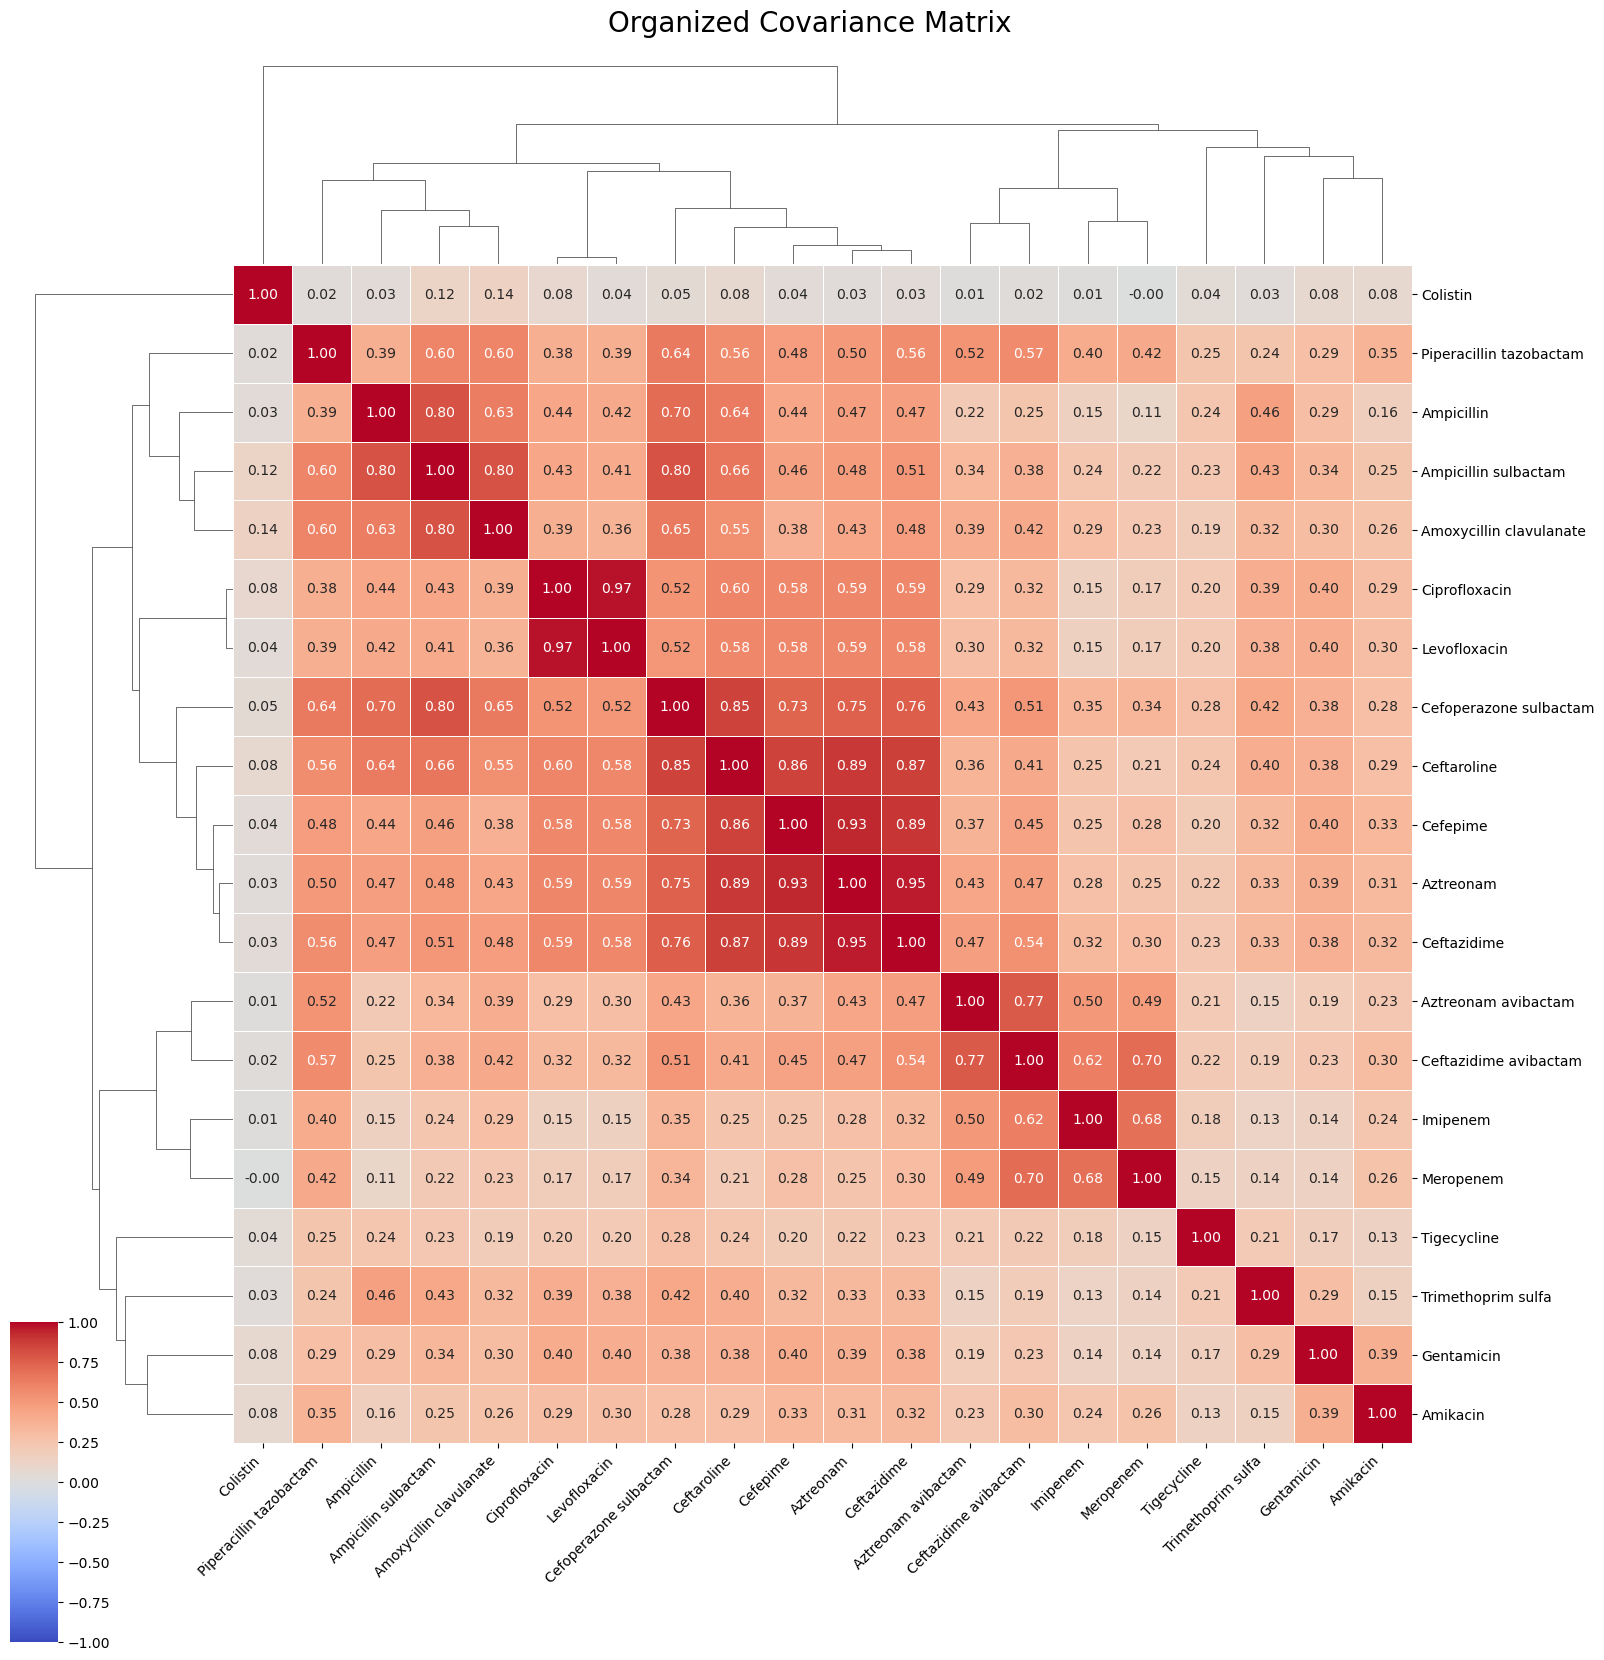

In [4]:
g = sns.clustermap(matriz_covarianza, 
                   cmap='coolwarm',         
                   
                   vmin=-1, vmax=1, center=0,
                   annot=True,            # Muestra los números
                   fmt=".2f",             # 2 decimales
                   figsize=(16, 16),      # Tamaño grande para ver bien
                   linewidths=.5,         # Líneas divisorias
                   dendrogram_ratio=0.15, # Tamaño del "árbol" de agrupación
                   cbar_pos=(0, 0, 0.03, 0.2)) # Posición de la barra de color

g.fig.suptitle('Organized Covariance Matrix', fontsize=20, y=1.02)

# Rotar las etiquetas para que se lean bien
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

plt.savefig("matriz_covarianza_heatmap.png", dpi=300) #guardar imagen
plt.show()

In [21]:
abio = df.columns.tolist()

def bivar(a1,a2):
    plt.figure(figsize=(6,5))
    plt.hist2d(df[a1], df[a2], bins=30, cmap="Blues", vmin=1, vmax=2000 )
    plt.colorbar(label="Frequency")
    plt.xlabel(a1)
    plt.ylabel(a2)
    plt.title(f"Bivariate Histogram: {a1} vs {a2}")
    plt.show()


In [22]:
abio

['Cefoperazone sulbactam',
 'Trimethoprim sulfa',
 'Ciprofloxacin',
 'Ampicillin sulbactam',
 'Gentamicin',
 'Colistin',
 'Aztreonam avibactam',
 'Aztreonam',
 'Ceftazidime avibactam',
 'Ceftaroline',
 'Imipenem',
 'Ceftazidime',
 'Meropenem',
 'Ampicillin',
 'Cefepime',
 'Piperacillin tazobactam',
 'Levofloxacin',
 'Tigecycline',
 'Amoxycillin clavulanate',
 'Amikacin']

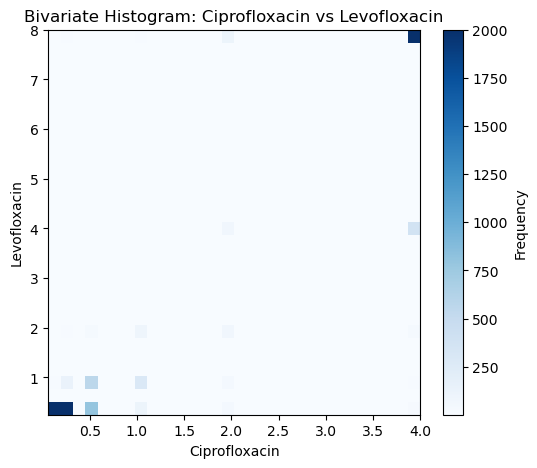

In [23]:
bivar('Ciprofloxacin','Levofloxacin')


-----------
 **PCA**
 ----------

INFORMATION: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [1]:
from sklearn.decomposition import PCA
#CÁLCULO DE PCA (SVD)
pca = PCA()
pca.fit(df_estandarizada_sklearn) #entrena el modelo con los datos estandarizados
componentes = pca.components_

NameError: name 'df_estandarizada_sklearn' is not defined


--- Captured Variance ---
PC      %  Ratio
 1 43.71% 0.4371
 2 11.14% 0.5484
 3  7.43% 0.6227
 4  5.81% 0.6808
 5  5.06% 0.7314
 6  4.52% 0.7766
 7  4.36% 0.8202
 8  3.72% 0.8574
 9  2.93% 0.8867
10  2.71% 0.9137
11  2.14% 0.9352
12  1.71% 0.9523
13  1.39% 0.9661


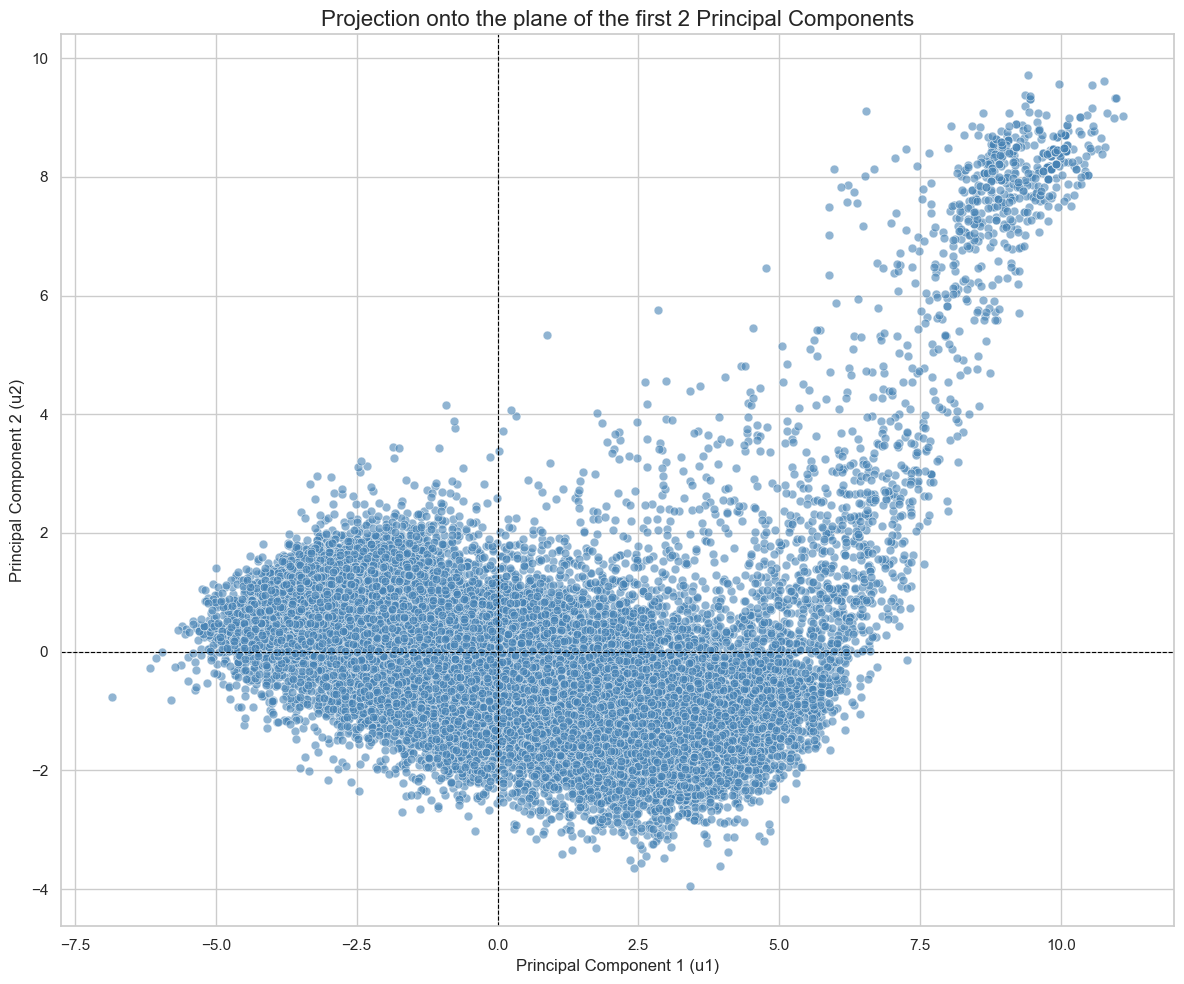

In [6]:
#GENERAR LA TABLA DE VARIANZA 

# Varianza explicada (%)
var_percent = pca.explained_variance_ratio_ * 100
# Ratio acumulado 
var_accumulated = np.cumsum(pca.explained_variance_ratio_)

tabla_varianza = pd.DataFrame({
    'PC': [f"{i+1}" for i in range(len(var_percent))], 
    '%': var_percent,
    'Ratio': var_accumulated
})

# Formateamos para que se vea bonito (redondeo)
print("\n--- Captured Variance ---")
print(tabla_varianza.head(13).to_string(index=False, formatters={
    '%': '{:.2f}%'.format,
    'Ratio': '{:.4f}'.format
}))

#Transformar los datos originales al nuevo espacio (Proyección.  Usamos el modelo PCA ya ajustado para obtener las coordenadas en PC1 y PC2
coordenadas_pca = pca.transform(df_estandarizada_sklearn)

#Crear un DataFrame temporal para facilitar el gráfico
df_plot = pd.DataFrame(data=coordenadas_pca[:, :2], columns=['PC1', 'PC2'])

#Generar el Scatter Plot (Gráfico de Dispersión)
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=df_plot, 
    color='steelblue', 
    alpha=0.6,         # Transparencia (útil porque tienes 33.000 puntos)
    s=40               # Tamaño de los puntos
)

# Líneas guía en el origen (0,0)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.title("Projection onto the plane of the first 2 Principal Components", fontsize=16)
plt.xlabel("Principal Component 1 (u1)")
plt.ylabel("Principal Component 2 (u2)")
plt.tight_layout()

plt.show()


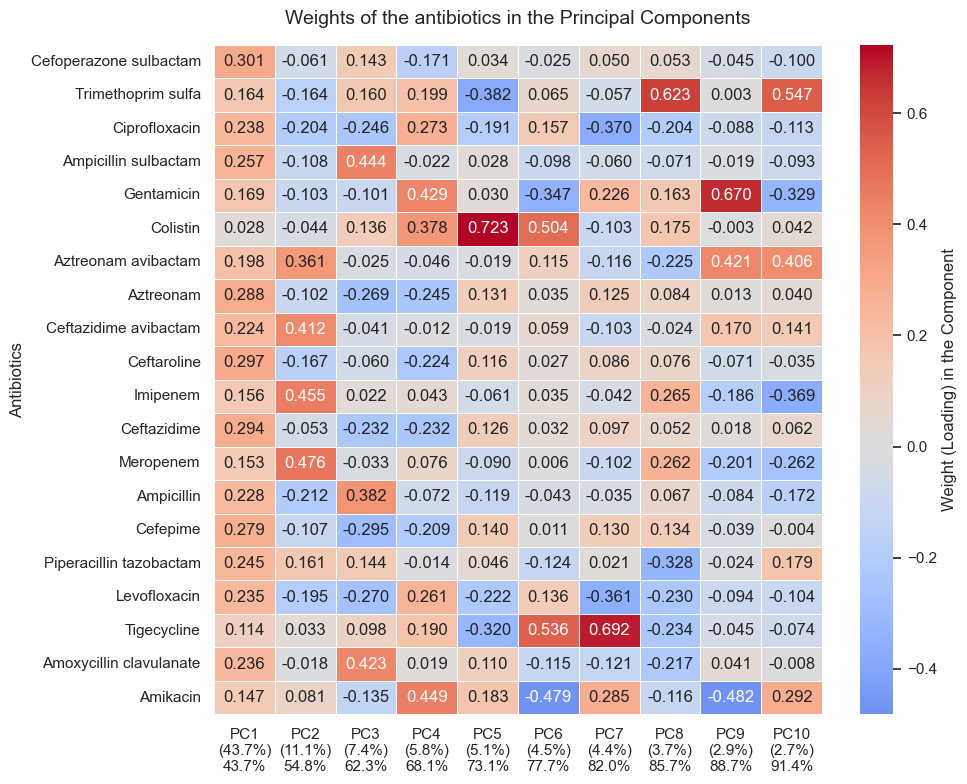

In [50]:
nombres_columnas = [f"PC{i+1}\n({var_percent[i]:.1f}%)\n{var_accumulated[i]*100:.1f}%" for i in range(len(var_percent))]

PLOT_componentes = pd.DataFrame(
    pca.components_.T,     #de aquí saca los componentes principales
    columns=nombres_columnas, 
    index=df.columns 
)

n_componentes_a_mostrar = 10 #cuantos componentes veo en la tabla
vectores_visuales = PLOT_componentes.iloc[:, :n_componentes_a_mostrar]

plt.figure(figsize=(10, 8)) 
sns.heatmap(
    vectores_visuales, 
    annot=True,          
    fmt=".3f",           
    cmap="coolwarm",     
    center=0,            
    linewidths=0.5,      
    cbar_kws={'label': 'Weight (Loading) in the Component'} 
)

plt.title("Weights of the antibiotics in the Principal Components", fontsize=14, pad=15)
plt.ylabel("Antibiotics", fontsize=12)
plt.xlabel("") # Lo dejo vacío porque las propias columnas ya dicen qué son


plt.xticks(rotation=0) # Aseguramos que las etiquetas de abajo se lean en horizontal
plt.tight_layout() 
plt.savefig(r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\pca10.png", dpi=300, bbox_inches="tight")
plt.show()


BASES: 

In [ ]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS

original one: 

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# =====================================================
# 1. LOAD DATA
# =====================================================

ruta = r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\DATA_eCOLI.xlsx"
df = pd.read_excel(ruta)

# Buscar dónde empiezan las columnas MIC
idx = df.columns.tolist().index("Cefoperazone sulbactam")
mic_cols = df.columns[idx:]

# Quedarnos solo con MICs
data = df[mic_cols].copy()

# Rellenar missing values con mediana
data = data.fillna(data.median())


# =====================================================
# 3. GREEDY FORWARD SELECTION
# =====================================================

total_variance_all = np.sum(np.var(data, axis=0)) * len(data)

selected_features = []
remaining = list(mic_cols)
explained_variances = []

print("RUNNING FEATURE SELECTION\n")

for step in range(10):

    best_score = -np.inf
    best_col = None

    for col in remaining:

        candidate_features = selected_features + [col]
        target_features = [c for c in mic_cols if c not in candidate_features]

        X = data[candidate_features]
        Y = data[target_features]

        model = LinearRegression()
        model.fit(X, Y)

        Y_pred = model.predict(X)

        rss = np.sum((Y.values - Y_pred) ** 2)

        explained_variance_ratio = 1 - (rss / total_variance_all)

        if explained_variance_ratio > best_score:
            best_score = explained_variance_ratio
            best_col = col

    selected_features.append(best_col)
    remaining.remove(best_col)
    explained_variances.append(best_score)

    print(
        f"Step {step+1}: Added {best_col} "
        f"(Cumulative Variance = {best_score*100:.2f}%)"
    )

# =====================================================
# 4. FINAL MODEL + EQUATIONS
# =====================================================

print("\nREGRESSION COEFFICIENTS\n")

target_features = [c for c in mic_cols if c not in selected_features]

X = data[selected_features]
Y = data[target_features]

model = LinearRegression()
model.fit(X, Y)

for i, target in enumerate(target_features):

    equation = f"{target} = {model.intercept_[i]:.4f}"

    for j, feature in enumerate(selected_features):

        coef = model.coef_[i][j]

        sign = "+" if coef >= 0 else "-"

        equation += f" {sign} {abs(coef):.4f}*{feature}"

    print(equation) 

RUNNING FEATURE SELECTION

Step 1: Added Aztreonam (Cumulative Variance = 57.88%)
Step 2: Added Ciprofloxacin (Cumulative Variance = 67.29%)
Step 3: Added Ampicillin sulbactam (Cumulative Variance = 74.58%)
Step 4: Added Trimethoprim sulfa (Cumulative Variance = 79.67%)
Step 5: Added Ceftazidime avibactam (Cumulative Variance = 84.16%)
Step 6: Added Gentamicin (Cumulative Variance = 87.30%)
Step 7: Added Piperacillin tazobactam (Cumulative Variance = 89.00%)
Step 8: Added Cefepime (Cumulative Variance = 90.63%)
Step 9: Added Cefoperazone sulbactam (Cumulative Variance = 92.09%)
Step 10: Added Ceftaroline (Cumulative Variance = 93.16%)

REGRESSION COEFFICIENTS

Colistin = -2.1404 - 0.0469*Aztreonam + 0.0220*Ciprofloxacin + 0.1090*Ampicillin sulbactam - 0.0198*Trimethoprim sulfa + 0.0215*Ceftazidime avibactam + 0.0263*Gentamicin - 0.0389*Piperacillin tazobactam + 0.0172*Cefepime - 0.0760*Cefoperazone sulbactam + 0.0742*Ceftaroline
Aztreonam avibactam = -3.0039 + 0.1776*Aztreonam + 0.0141

In [6]:
import pandas as pd

import numpy as np

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split



# ==========================================================

# 1. Load Data

# ==========================================================

data_path = r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\DATA_eCOLI.xlsx"

df = pd.read_excel(data_path)



# MIC columns

idx = df.columns.tolist().index("Cefoperazone sulbactam")

mic_cols = df.columns[idx:]



# MIC data

data = df[mic_cols].copy()



# ==========================================================

# 2. Train / Validation Split

# ==========================================================



# 80% work, 20% validation

work_data, val_data = train_test_split(

    data,

    test_size=0.2,

    random_state=42

)



print("Work set:", work_data.shape)

print("Validation set:", val_data.shape)



# ==========================================================

# 3. Greedy Forward Selection (TRAINING ONLY)

# ==========================================================



# Total variance computed ONLY on work set

total_variance_work = (

    np.sum(np.var(work_data, axis=0)) * len(work_data)

)



total_variance_val = (

    np.sum(np.var(val_data, axis=0)) * len(val_data)

)



selected_features = []

remaining = list(mic_cols)

explained_variances_work = []

explained_variances_val = []



print("- RUNNING FEATURE SELECTION")



for step in range(10):



    best_score = -float('inf')

    best_col = None



    for col in remaining:



        candidate_features = selected_features + [col]

        target_features = [

            c for c in mic_cols

            if c not in candidate_features

        ]



        # ---------------- TRAIN ----------------

        X_train = work_data[candidate_features]

        Y_train = work_data[target_features]



        model = LinearRegression()

        model.fit(X_train, Y_train)



        Y_pred_train = model.predict(X_train)



        rss_train = np.sum(

            (Y_train.values - Y_pred_train)**2

        )



        explained_train = (

            1 - (rss_train / total_variance_work)

        )



        if explained_train > best_score:

            best_score = explained_train

            best_col = col



    # Add best feature

    selected_features.append(best_col)

    remaining.remove(best_col)



    # ======================================================

    # VALIDATE CURRENT MODEL

    # ======================================================



    target_features = [

        c for c in mic_cols

        if c not in selected_features

    ]



    X_train = work_data[selected_features]

    Y_train = work_data[target_features]



    X_val = val_data[selected_features]

    Y_val = val_data[target_features]



    model = LinearRegression()

    model.fit(X_train, Y_train)



    # Training variance

    Y_pred_train = model.predict(X_train)



    rss_train = np.sum(

        (Y_train.values - Y_pred_train)**2

    )



    explained_train = (

        1 - (rss_train / total_variance_work)

    )



    # Validation variance

    Y_pred_val = model.predict(X_val)



    rss_val = np.sum(

        (Y_val.values - Y_pred_val)**2

    )



    explained_val = (

        1 - rss_val / total_variance_val

    )

       



    explained_variances_val.append(explained_val)



    print(

        f"Step {step+1}: "

        f"Added {best_col} | "

        f"Train={explained_train*100:.2f}% | "

        f"Validation={explained_val*100:.2f}%"

    )



# ==========================================================

# 4. Final Regression Equations

# ==========================================================



print("\n--- FINAL MODEL")



target_features = [

    c for c in mic_cols

    if c not in selected_features

]



X_train = work_data[selected_features]

Y_train = work_data[target_features]



model = LinearRegression()

model.fit(X_train, Y_train)



for i, target in enumerate(target_features):



    equation = f"{target} = {model.intercept_[i]:.4f}"



    for j, feature in enumerate(selected_features):



        coef = model.coef_[i][j]

        sign = "+" if coef >= 0 else "-"



        equation += (

            f" {sign} {abs(coef):.4f}*{feature}"

        )



    print("\n" + equation) 

Work set: (26174, 20)
Validation set: (6544, 20)
- RUNNING FEATURE SELECTION
Step 1: Added Aztreonam | Train=57.86% | Validation=57.96%
Step 2: Added Ciprofloxacin | Train=67.32% | Validation=67.15%
Step 3: Added Ampicillin sulbactam | Train=74.61% | Validation=74.46%
Step 4: Added Trimethoprim sulfa | Train=79.70% | Validation=79.54%
Step 5: Added Ceftazidime avibactam | Train=84.10% | Validation=84.35%
Step 6: Added Gentamicin | Train=87.26% | Validation=87.45%
Step 7: Added Piperacillin tazobactam | Train=88.97% | Validation=89.13%
Step 8: Added Cefepime | Train=90.59% | Validation=90.77%
Step 9: Added Cefoperazone sulbactam | Train=92.05% | Validation=92.22%
Step 10: Added Ceftaroline | Train=93.13% | Validation=93.27%

--- FINAL MODEL

Colistin = -2.1413 - 0.0510*Aztreonam + 0.0199*Ciprofloxacin + 0.1089*Ampicillin sulbactam - 0.0199*Trimethoprim sulfa + 0.0208*Ceftazidime avibactam + 0.0287*Gentamicin - 0.0410*Piperacillin tazobactam + 0.0195*Cefepime - 0.0722*Cefoperazone sulbac

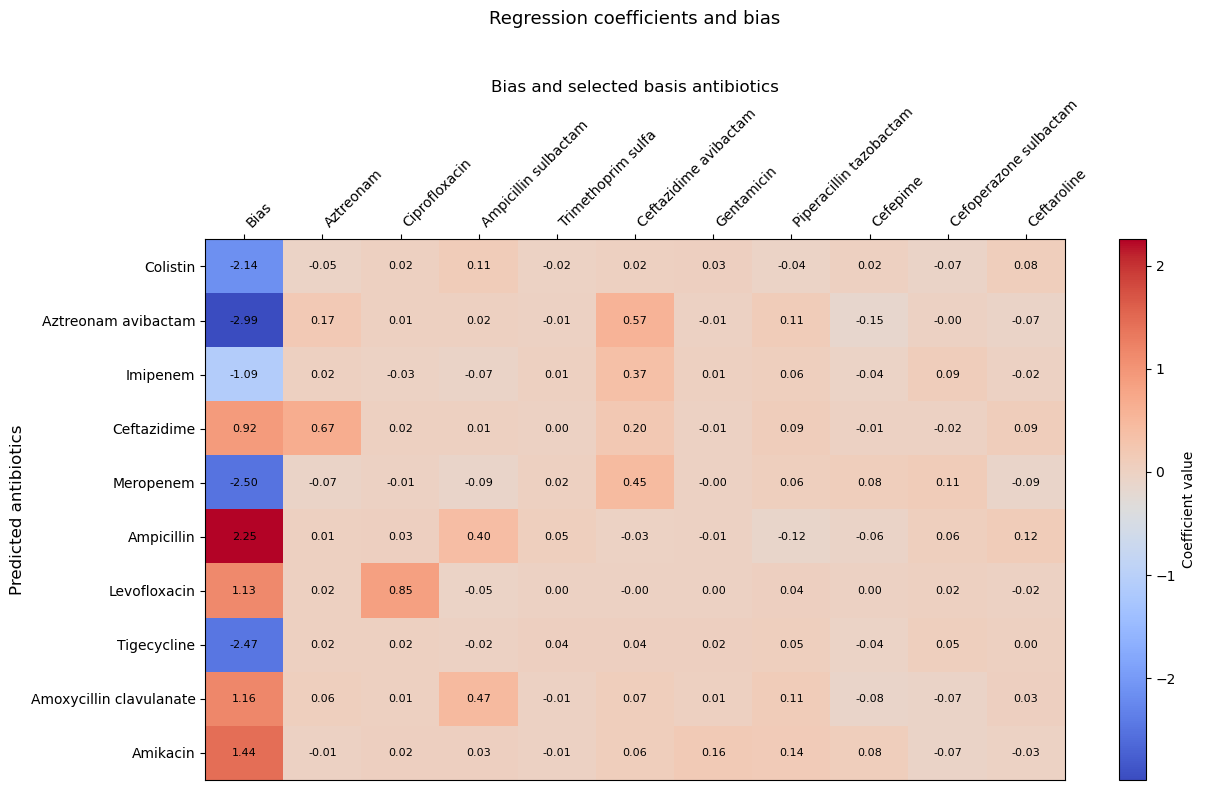

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Create coefficient matrix INCLUDING bias/intercept
# =====================================================

coef_matrix = pd.DataFrame(
    model.coef_,
    index=target_features,
    columns=selected_features
)

# Add bias as first column
coef_matrix.insert(
    0,
    "Bias",
    model.intercept_
)

# =====================================================
# Plot heatmap
# =====================================================

plt.figure(figsize=(13,8))

im = plt.imshow(
    coef_matrix.values,
    aspect='auto',
    cmap='coolwarm'
)

# Y axis: predicted antibiotics
plt.yticks(
    np.arange(len(target_features)),
    coef_matrix.index,
    fontsize=10
)

# X axis on top: basis antibiotics + bias
plt.xticks(
    np.arange(len(coef_matrix.columns)),
    coef_matrix.columns,
    rotation=45,
    ha='left',
    fontsize=10
)

ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xlabel("Bias and selected basis antibiotics", fontsize=12)
plt.ylabel("Predicted antibiotics", fontsize=12)

plt.title(
    "Regression coefficients and bias",
    pad=40,
    fontsize=13
)

# Numbers inside cells
for i in range(coef_matrix.shape[0]):
    for j in range(coef_matrix.shape[1]):
        plt.text(
            j,
            i,
            f"{coef_matrix.iloc[i,j]:.2f}",
            ha='center',
            va='center',
            fontsize=8
        )

cbar = plt.colorbar(im)
cbar.set_label("Coefficient value")

ax = plt.gca()
ax.grid(False)
plt.tight_layout()
plt.show()
